# Jaguar Re-ID — ResNet-34 Improved v5

**Architecture** : ResNet-34 (BatchNorm + ReLU, Dropout 0.4, AdamW)  
**Expérience** : Sweep avec augmentation `heavy` (meilleures performances sweep) + **retrain final SANS augmentation** → embeddings extraits d'images propres pour le Re-ID

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs, make_dataset

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775948869.404660  187702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775948869.567750  187702 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775948870.726894  187702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1775948872.350168  187702 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE    = 224
NUM_CLASSES = 31
BATCH_SIZE  = 64
SEED        = 42

MODEL_NAME   = 'resnet34_improved_v5'
AUGMENTATION = 'heavy'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# IMPORTANT: On utilise 'heavy' pour le sweep (meilleure régularisation)
# mais le retrain final sera SANS augmentation (embeddings propres)
RETRAIN_AUGMENTATION = 'none'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)


In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)
val_ds   = make_dataset(X_val, y_val, batch_size=BATCH_SIZE)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1775948875.864200  187702 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775948876.011446  187702 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 24 | Val batches: 6


## 2. ResNet-34 architecture (corrected)

Corrections vs notebook 06 :
- Conv → **BatchNorm → ReLU** (au lieu de Conv → tanh)
- Shortcut projection : Conv1x1 → **BatchNorm**
- **Dropout(0.4)** avant la couche de classification

In [4]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes):
    inputs = keras.Input(input_shape)
    x = inputs

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model():
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.
L'augmentation est appliquée dans le pipeline de données (`make_dataset`).

In [5]:
WEIGHT_DECAY = 5e-4

def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (resnet34_improved_v5) ===


I0000 00:00:1775948885.140342  187855 service.cc:153] XLA service 0x7f0a3c0844f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775948885.140453  187855 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775948885.419690  187855 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775948886.556502  187855 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775948886.764943  187855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25722__.238
I0000 00:00:1775948895.626534  187855 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1775948898.422060  187856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25722__

  lr_0.001: val_acc=0.8865 (best epoch=68)


I0000 00:00:1775949121.399477  187853 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96890__.238
I0000 00:00:1775949128.211539  187852 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96890__.238


  lr_0.0005: val_acc=0.9129 (best epoch=66)


I0000 00:00:1775949342.093549  187852 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_168296__.238
I0000 00:00:1775949348.826688  187856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_168296__.238


  lr_0.0001: val_acc=0.0369 (best epoch=1)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0005,0.912929,66
1,lr_0.001,0.886544,68
2,lr_0.0001,0.036939,1



Best: lr_0.0005 → val_acc=0.9129


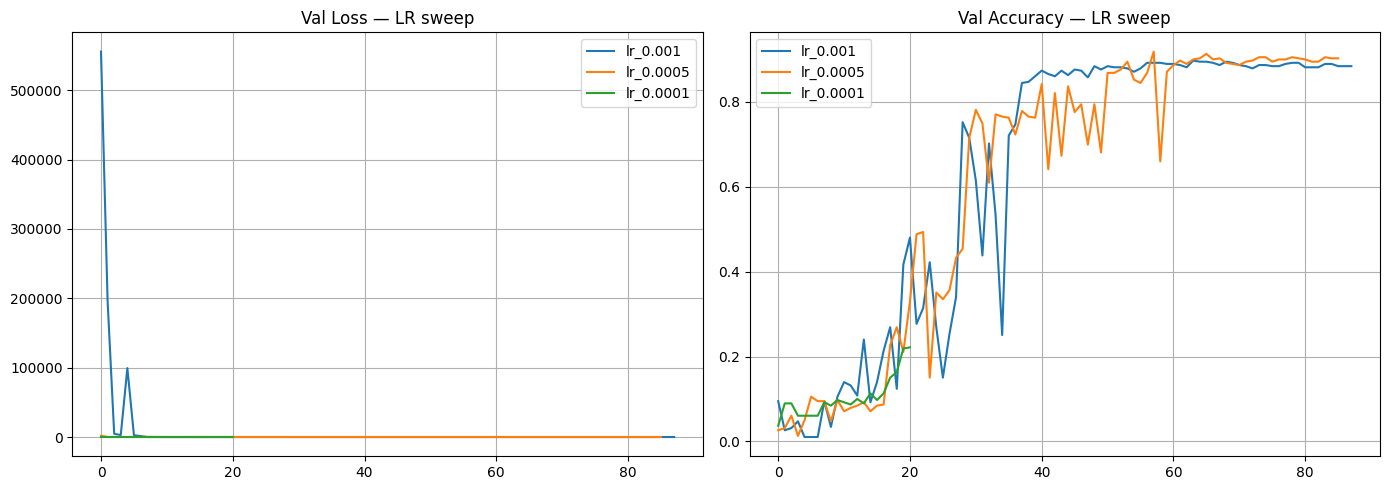

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775949410.346514  187852 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_204125__.238


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0965 - loss: 4.1166

I0000 00:00:1775949417.038040  187854 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_204125__.238


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 422ms/step - accuracy: 0.1036 - loss: 3.8644 - val_accuracy: 0.0607 - val_loss: 9.0201 - learning_rate: 5.0000e-04
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.1629 - loss: 3.2217 - val_accuracy: 0.0607 - val_loss: 19.9348 - learning_rate: 5.0000e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.2546 - loss: 2.7601 - val_accuracy: 0.0607 - val_loss: 22.2332 - learning_rate: 5.0000e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.3496 - loss: 2.4620 - val_accuracy: 0.0607 - val_loss: 23.6698 - learning_rate: 5.0000e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.3773 - loss: 2.2256 - val_accuracy: 0.0343 - val_loss: 20.1242 - learning_rate: 5.0000e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.4241 - loss: 2.1002 - val_accuracy: 0.0607 - val_loss: 17.1565 - learning_rate: 5.0000e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy:

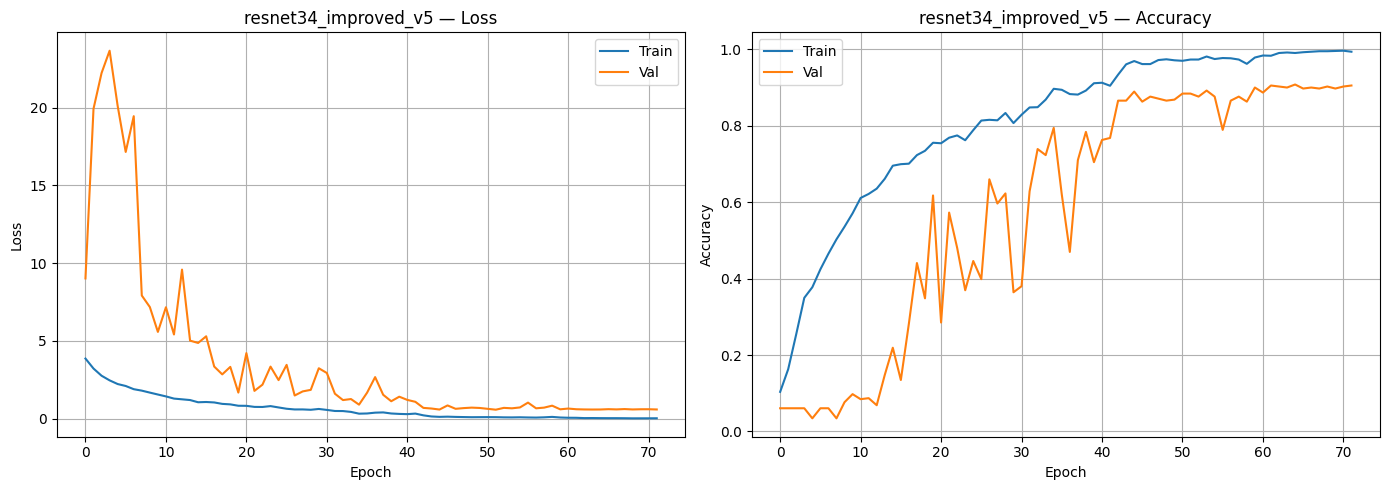

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

resnet34_improved_v5 (best LR=0.0005):
  Train — Loss: 0.0964, Acc: 0.9716
  Val   — Loss: 0.5750, Acc: 0.8839


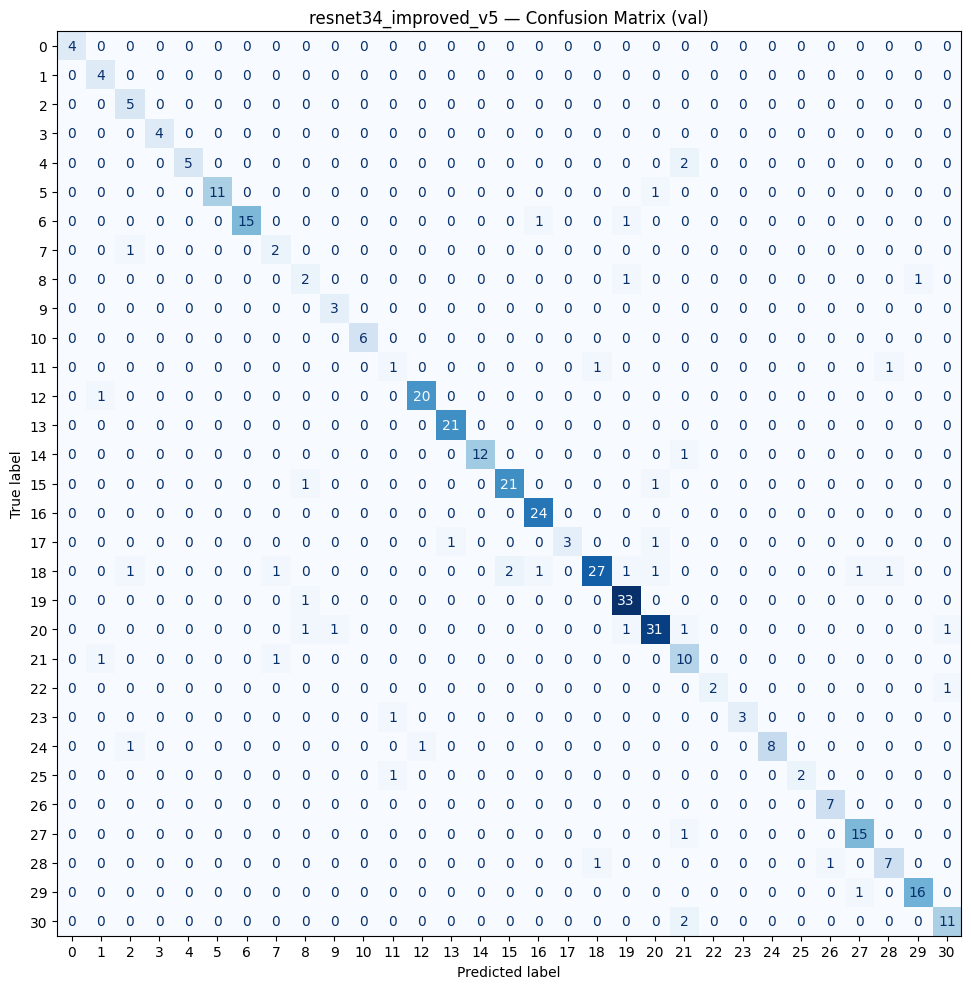

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# CHANGEMENT CLÉ : retrain final SANS augmentation
# On garde les hyperparams trouvés avec heavy (meilleur sweep)
# mais on retrain sur images propres pour des embeddings discriminants
all_ds = make_dataset(X_all, y_all, training=True, augmentation=RETRAIN_AUGMENTATION, batch_size=BATCH_SIZE)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")
print(f"Sweep augmentation: {AUGMENTATION} | Retrain augmentation: {RETRAIN_AUGMENTATION}")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds,
    epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")


Retraining on full dataset (1895 images) for 66 epochs
Sweep augmentation: heavy | Retrain augmentation: none
Epoch 1/66


I0000 00:00:1775949670.013366  187855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2051978__.238


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1096 - loss: 4.0234

I0000 00:00:1775949677.279443  187853 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2051978__.238
I0000 00:00:1775949679.285655  211100 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 16 bytes spill stores, 16 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 355ms/step - accuracy: 0.1852 - loss: 3.3386
Epoch 2/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3662 - loss: 2.3802
Epoch 3/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4971 - loss: 1.8701
Epoch 4/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5989 - loss: 1.4357
Epoch 5/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6897 - loss: 1.1377
Epoch 6/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7103 - loss: 1.0036
Epoch 7/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7615 - loss: 0.8760
Epoch 8/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7826 - loss: 0.7353
Epoch 9/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8427 - loss: 0.5763
Epoch 10/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8533 - loss: 0.4783
Epoch 11/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9013 - loss: 0.3386
Epoch 12/66
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9050 -

In [14]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step
Embedding shape: (371, 512)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v5.csv


,row_id,similarity
0,0,0.758901
1,1,0.755636
2,2,0.730955
3,3,0.605371
4,4,0.716048


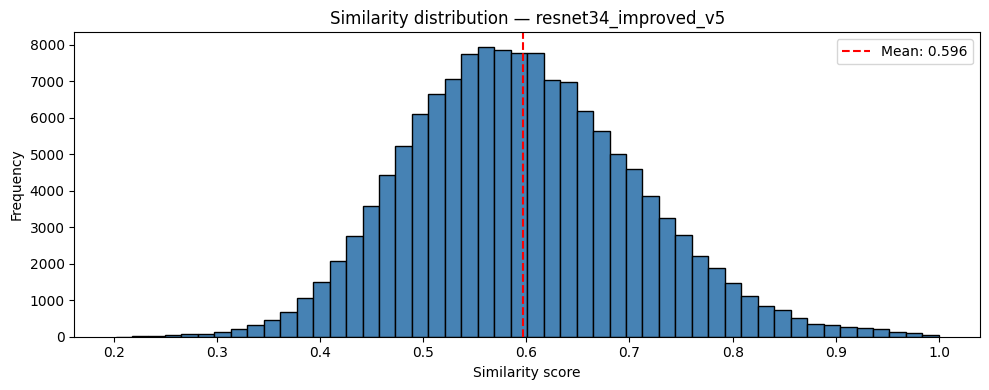

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [16]:
print(f"""
ResNet-34 improved v5:
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Best epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}
  Régularisation: AdamW (wd={WEIGHT_DECAY}), Dropout(0.4)
  Sweep augmentation: {AUGMENTATION} (data pipeline via make_dataset)
  Retrain augmentation: {RETRAIN_AUGMENTATION} (images propres pour embeddings)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> {submission_path}
""")



ResNet-34 improved v5:
  Train - Loss: 0.0964, Acc: 0.9716
  Val   - Loss: 0.5750, Acc: 0.8839
  Best epoch: 66
  Embedding dim: 512
  Régularisation: AdamW (wd=0.0005), Dropout(0.4)
  Sweep augmentation: heavy (data pipeline via make_dataset)
  Retrain augmentation: none (images propres pour embeddings)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v5.csv



## 7. Observations & Verdict

### Results

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Overfitting ? | — | TODO |
| Kaggle Score (public) | — | TODO |
| Kaggle Score (private) | — | TODO |

### Analysis

**Hypothèse testée** : l'augmentation `heavy` donne les meilleurs hyperparams (LR sweep = 90.77 %, le plus haut de la série), mais l'augmentation pendant le retrain final dégrade les embeddings pour le Re-ID. En séparant les deux phases (sweep avec aug, retrain sans aug), on peut combiner le meilleur des deux mondes.

**Ce qui change vs 06_4 :**
- Sweep : identique (heavy augmentation → même BEST_LR et BEST_EPOCH)
- Retrain final : `augmentation='none'` → le modèle est entraîné sur les images originales non transformées
- Embeddings : extraits d'un modèle qui a vu les images "propres" → plus fins, plus discriminants pour la similarité cosine

**Points à surveiller :**
- Le retrain sans aug va probablement donner train_acc=100 % (mémorisation) — c'est attendu et acceptable car on veut des embeddings nets, pas de la généralisation
- Le score Kaggle devrait être plus haut que 06_4 (0.452) si l'hypothèse est correcte
- Comparer avec 06_2 (no-aug total, Kaggle=0.566) : est-ce que les hyperparams du sweep heavy donnent de meilleurs embeddings que ceux du sweep no-aug ?

### Verdict

- [ ] Improvable -> Prochaines pistes : loss métrique (ArcFace/triplet), label smoothing, dropout tuning
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this approach, why ?

### Interpretation

_Free Space : On note ce qu'on a à dire sur ce notebook, servira pour la soutenance._
